<a href="https://colab.research.google.com/github/RaffyNadjib/Tugas-PCD-Per5/blob/main/Tugas_PCD_Per5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Berhasil memuat gambar: gambar.jpg


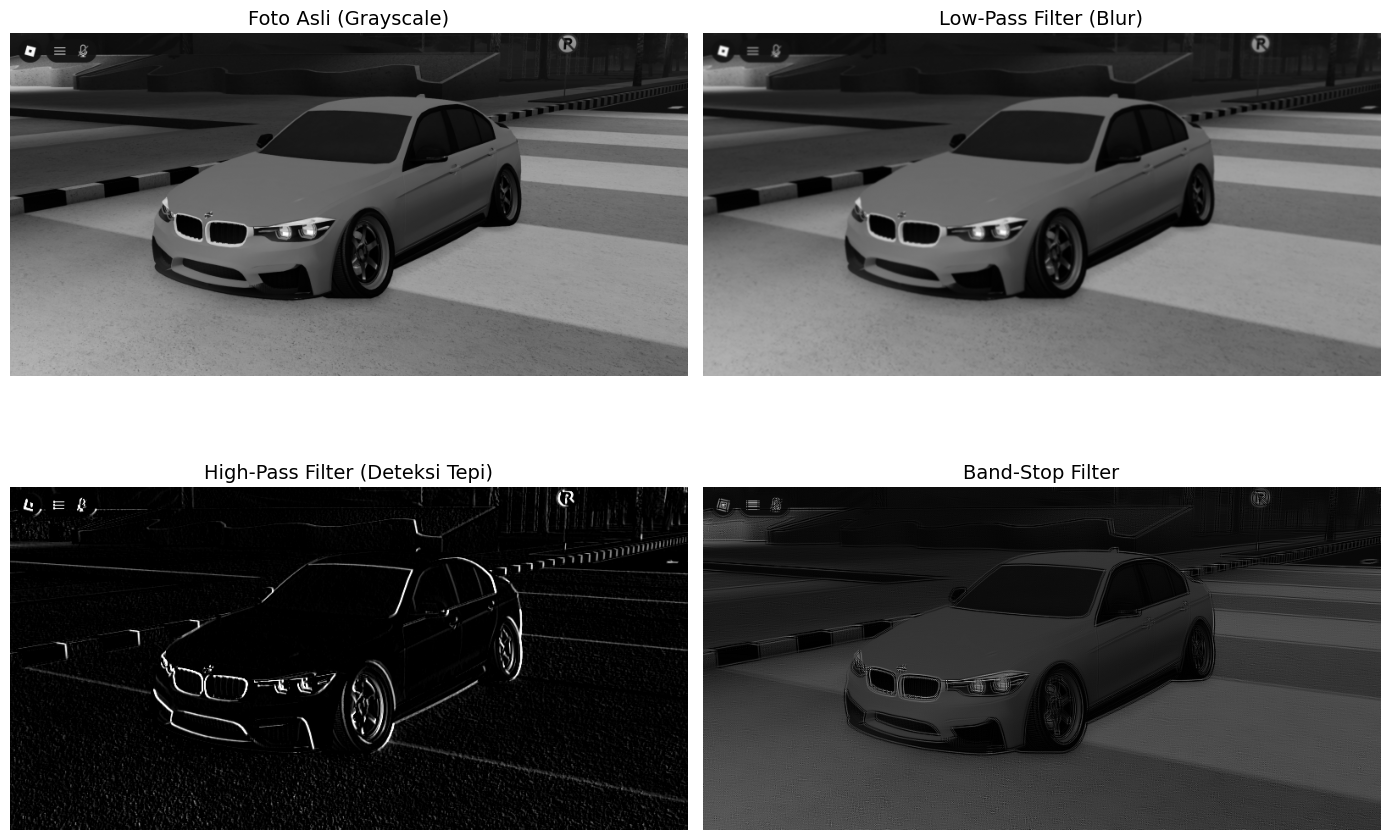

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. GANTI NAMA FILE DI SINI
# ==========================================
# Ketik nama file foto Anda beserta ekstensinya (misal: .jpg, .png)
nama_file = "gambar.jpg"

# ==========================================
# 2. MEMBACA & MENYIAPKAN GAMBAR
# ==========================================
img = cv2.imread(nama_file)

# Pengecekan apakah gambar berhasil ditemukan
if img is None:
    print(f"❌ ERROR: File '{nama_file}' tidak ditemukan!")
    print("Pastikan penulisan nama file benar (termasuk huruf besar/kecil) dan file sudah ada di folder yang sama dengan kode ini.")
else:
    print(f"✅ Berhasil memuat gambar: {nama_file}")

    # Ubah ke Grayscale
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # (Opsional) Perkecil ukuran gambar agar proses tampil lebih cepat
    rasio = 800.0 / img_gray.shape[1]
    dimensi_baru = (800, int(img_gray.shape[0] * rasio))
    img_gray = cv2.resize(img_gray, dimensi_baru, interpolation=cv2.INTER_AREA)

    # ==========================================
    # 3. DEFINISI KETIGA FILTER KERNEL
    # ==========================================
    H_LPF = np.array([
        [1, 1, 1],
        [1, 4, 1],
        [1, 1, 1]
    ]) / 12.0

    H_HPF = np.array([
        [-1,  0,  1],
        [-1,  0,  3],
        [-3,  0,  1]
    ])

    H_BSF = np.array([
        [ 1.0, -1.0,  1.0],
        [-1.0,  0.5, -1.0],
        [ 1.0, -1.0,  1.0]
    ])

    # ==========================================
    # 4. PROSES KONVOLUSI
    # ==========================================
    hasil_lpf = cv2.filter2D(img_gray, -1, H_LPF)
    hasil_hpf = cv2.filter2D(img_gray, -1, H_HPF)
    hasil_bsf = cv2.filter2D(img_gray, -1, H_BSF)

    # ==========================================
    # 5. MENAMPILKAN HASILNYA
    # ==========================================
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ax = axes.ravel()

    ax[0].imshow(img_gray, cmap='gray')
    ax[0].set_title('Foto Asli (Grayscale)', fontsize=14)

    ax[1].imshow(hasil_lpf, cmap='gray')
    ax[1].set_title('Low-Pass Filter (Blur)', fontsize=14)

    ax[2].imshow(hasil_hpf, cmap='gray')
    ax[2].set_title('High-Pass Filter (Deteksi Tepi)', fontsize=14)

    ax[3].imshow(hasil_bsf, cmap='gray')
    ax[3].set_title('Band-Stop Filter', fontsize=14)

    for a in ax:
        a.axis('off')

    plt.tight_layout()
    plt.show()

✅ Berhasil memuat gambar berwarna: gambar.jpg


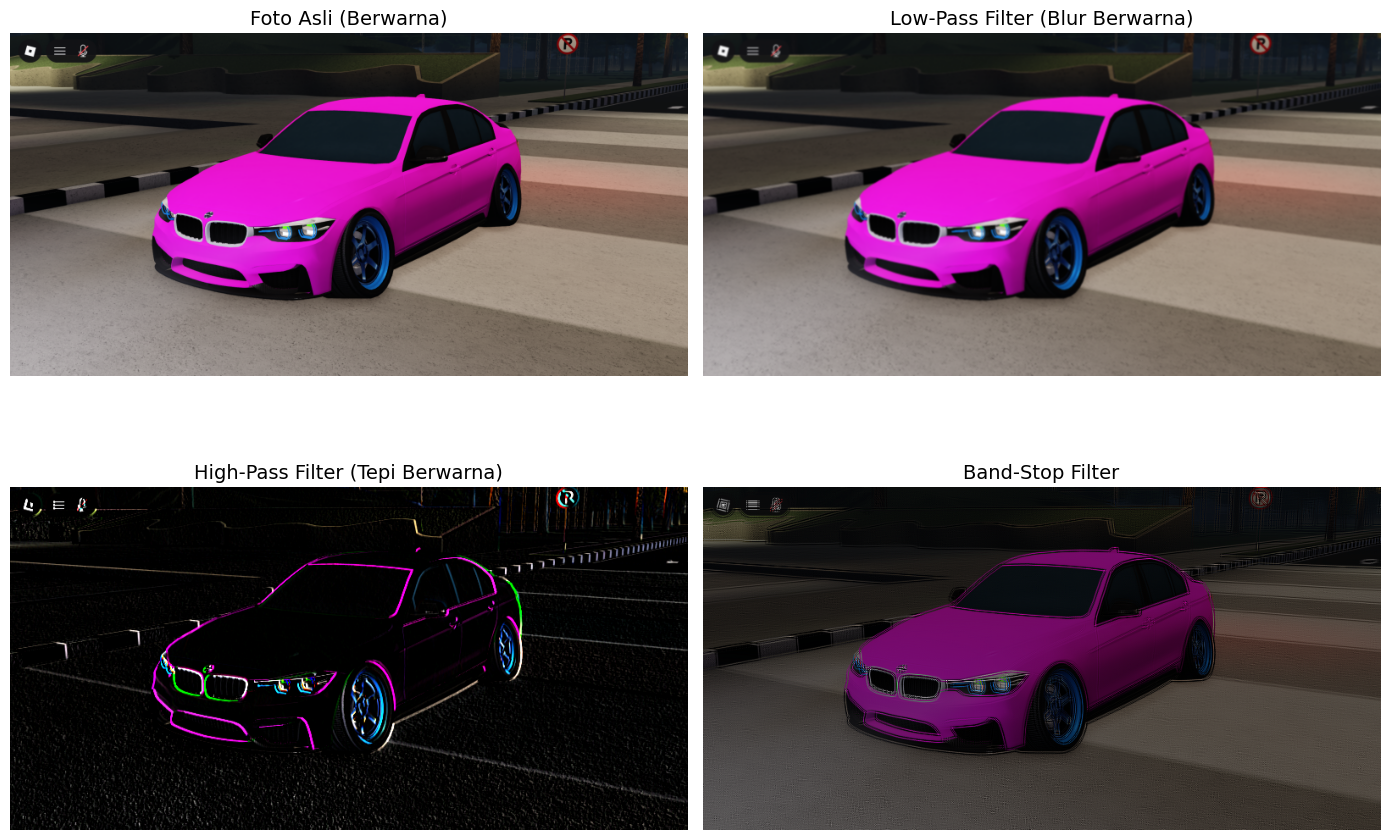

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. GANTI NAMA FILE DI SINI
# ==========================================
nama_file = "gambar.jpg"

img = cv2.imread(nama_file)

if img is None:
    print(f"❌ ERROR: File '{nama_file}' tidak ditemukan!")
else:
    print(f"✅ Berhasil memuat gambar berwarna: {nama_file}")

    # ==========================================
    # 2. PENTING: KONVERSI BGR KE RGB
    # ==========================================
    # Secara default, OpenCV membaca format warna secara terbalik yaitu BGR (Blue-Green-Red).
    # Agar warnanya tidak aneh saat ditampilkan di Matplotlib, kita balik urutannya ke RGB.
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # (Opsional) Perkecil ukuran gambar
    rasio = 800.0 / img_rgb.shape[1]
    dimensi_baru = (800, int(img_rgb.shape[0] * rasio))
    img_rgb = cv2.resize(img_rgb, dimensi_baru, interpolation=cv2.INTER_AREA)

    # ==========================================
    # 3. DEFINISI KETIGA FILTER KERNEL
    # ==========================================
    H_LPF = np.array([
        [1, 1, 1],
        [1, 4, 1],
        [1, 1, 1]
    ]) / 12.0

    H_HPF = np.array([
        [-1,  0,  1],
        [-1,  0,  3],
        [-3,  0,  1]
    ])

    H_BSF = np.array([
        [ 1.0, -1.0,  1.0],
        [-1.0,  0.5, -1.0],
        [ 1.0, -1.0,  1.0]
    ])

    # ==========================================
    # 4. PROSES KONVOLUSI (Langsung ke Gambar Berwarna)
    # ==========================================
    hasil_lpf = cv2.filter2D(img_rgb, -1, H_LPF)
    hasil_hpf = cv2.filter2D(img_rgb, -1, H_HPF)
    hasil_bsf = cv2.filter2D(img_rgb, -1, H_BSF)

    # ==========================================
    # 5. MENAMPILKAN HASILNYA
    # ==========================================
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ax = axes.ravel()

    ax[0].imshow(img_rgb)
    ax[0].set_title('Foto Asli (Berwarna)', fontsize=14)

    ax[1].imshow(hasil_lpf)
    ax[1].set_title('Low-Pass Filter (Blur Berwarna)', fontsize=14)

    ax[2].imshow(hasil_hpf)
    ax[2].set_title('High-Pass Filter (Tepi Berwarna)', fontsize=14)

    ax[3].imshow(hasil_bsf)
    ax[3].set_title('Band-Stop Filter', fontsize=14)

    for a in ax:
        a.axis('off')

    plt.tight_layout()
    plt.show()

In [7]:
import numpy as np
from scipy.signal import convolve2d

# ==========================================
# 1. MATRIKS CITRA ASLI (X)
# ==========================================
X = np.array([
    [1, 0, 0, 0],
    [1, 1, 1, 0],
    [1, 1, 1, 0],
    [1, 0, 0, 0]
])

# ==========================================
# 2. KOLEKSI MATRIKS FILTER KERNEL (H)
# ==========================================
# Catatan: Untuk LPF di sini, kita tidak membaginya dengan 12
# agar hasil angkanya persis (bulat) seperti contoh di slide Anda.
# Jika untuk gambar asli, LPF harus dibagi 12.0.

filters = {
    "Low-Pass Filter": np.array([
        [1, 1, 1],
        [1, 4, 1],
        [1, 1, 1]
    ]),

    "High-Pass Filter": np.array([
        [-1,  0,  1],
        [-1,  0,  3],
        [-3,  0,  1]
    ]),

    "Band-Stop Filter": np.array([
        [ 1.0, -1.0,  1.0],
        [-1.0,  0.5, -1.0],
        [ 1.0, -1.0,  1.0]
    ])
}

# ==========================================
# 3. FUNGSI UNTUK MENGHITUNG KONVOLUSI
# ==========================================
def hitung_filter(nama_filter):
    # Mengambil matriks kernel berdasarkan nama
    H = filters[nama_filter]

    # Melakukan konvolusi dengan Zero Padding (menambahkan 0 di luar tepi matriks X)
    # mode='same' mempertahankan ukuran X (4x4)
    Y = convolve2d(X, H, mode='same', boundary='fill', fillvalue=0)

    print(f"\n{'='*40}")
    print(f" HASIL KONVOLUSI: {nama_filter.upper()}")
    print(f"{'='*40}")
    print("Filter Kernel (H):")
    print(H)
    print("\nMatriks Hasil (Y):")
    print(Y)

# ==========================================
# 4. EKSEKUSI KODE UNTUK SEMUA FILTER
# ==========================================
print("Matriks Citra Asli (X):")
print(X)

# Looping untuk menampilkan hasil dari ketiga filter
for nama in filters.keys():
    hitung_filter(nama)

Matriks Citra Asli (X):
[[1 0 0 0]
 [1 1 1 0]
 [1 1 1 0]
 [1 0 0 0]]

 HASIL KONVOLUSI: LOW-PASS FILTER
Filter Kernel (H):
[[1 1 1]
 [1 4 1]
 [1 1 1]]

Matriks Hasil (Y):
[[ 6  4  2  1]
 [ 8 10  7  2]
 [ 8 10  7  2]
 [ 6  4  2  1]]

 HASIL KONVOLUSI: HIGH-PASS FILTER
Filter Kernel (H):
[[-1  0  1]
 [-1  0  3]
 [-3  0  1]]

Matriks Hasil (Y):
[[-1  3  1  1]
 [-2  3  4  4]
 [-4  1  4  4]
 [-3  1  1  1]]

 HASIL KONVOLUSI: BAND-STOP FILTER
Filter Kernel (H):
[[ 1.  -1.   1. ]
 [-1.   0.5 -1. ]
 [ 1.  -1.   1. ]]

Matriks Hasil (Y):
[[ 0.5  0.   0.   1. ]
 [-1.5  0.5 -0.5  0. ]
 [-1.5  0.5 -0.5  0. ]
 [ 0.5  0.   0.   1. ]]
